# Notebook 4 — Modello Transformer

Obiettivo: addestrare e valutare il Transformer su tutti e 4 i sotto-dataset CMAPSS, con la stessa procedura dell'LSTM per un confronto fair.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from src.models.transformer_model import build_transformer
from src.training import run_experiment

DATA_DIR = '../data/processed'
MODEL_DIR = '../saved_models'

## Perché questa architettura Transformer

Il Transformer è adattato per la regressione su serie temporali brevi (30 timestep). La struttura segue l'encoder del paper originale (Vaswani et al., 2017), con alcune scelte specifiche per questo task.

**Perché d_model = 64?**
`d_model` è la dimensione dello spazio interno in cui operano tutti i layer del Transformer. 64 è sufficiente per sequenze di 30 timestep con 17 feature: abbastanza ricco da rappresentare i pattern di degrado, abbastanza piccolo da non richiedere enormi quantità di dati. Un primo `Dense(64)` proietta i 17 sensori in questo spazio prima di entrare nel Transformer.

**Perché 4 attention head?**
Con `num_heads=4` ogni head opera su uno spazio di dimensione `64/4 = 16`. Quattro head paralleli permettono al modello di imparare contemporaneamente relazioni diverse tra i timestep: un head può concentrarsi sulle tendenze a breve termine, un altro sulle variazioni lente. Con `num_heads=2` si avrebbe meno diversità; con 8 lo spazio per head diventerebbe troppo ridotto (8 dimensioni).

**Perché ff_dim = 128?**
La FFN interna al blocco encoder ha dimensione 128 = 2× d_model. Questo rapporto è lo standard del paper originale: la FFN espande la rappresentazione per catturare interazioni non lineari, poi la riporta a d_model. Valori più grandi (4×) sono comuni in NLP ma non necessari per sequenze industriali brevi.

**Perché 2 blocchi encoder?**
2 blocchi sono sufficienti per sequenze di 30 timestep. Ogni blocco aggiunge un livello di astrazione; con sequenze corte, 3+ blocchi non portano guadagni e aumentano il rischio di overfitting. Il Transformer converge già in poche epoche, segno che l'architettura è adeguata alla complessità del task.

**Perché GlobalAveragePooling1D invece dell'ultimo token?**
A differenza dei modelli NLP che usano il token `[CLS]` finale, per la regressione RUL è più stabile aggregare **tutti i 30 timestep** con la media. Ogni timestep contribuisce alla predizione finale, sfruttando l'intera finestra temporale invece di dipendere da un solo punto.

**Codifica posizionale sinusoidale:** nessun parametro apprendibile, formula deterministica (`PE(pos,2i)=sin(pos/10000^(2i/d))`). Più stabile da addestrare rispetto agli embedding posizionali appresi, e senza parametri aggiuntivi — vantaggio significativo con dataset relativamente piccoli come CMAPSS.

In [2]:
results = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    X_train = np.load(f'{DATA_DIR}/X_train_{fd}.npy')
    y_train = np.load(f'{DATA_DIR}/y_train_{fd}.npy')
    X_test  = np.load(f'{DATA_DIR}/X_test_{fd}.npy')
    y_test  = np.load(f'{DATA_DIR}/y_test_{fd}.npy')

    window_size = X_train.shape[1]  # 30
    n_features  = X_train.shape[2]  # 17

    # Costruisco il Transformer con gli iperparametri scelti
    model = build_transformer(
        window_size, n_features,
        d_model=64,    # dimensione embedding
        num_heads=4,   # 4 head di attention paralleli
        ff_dim=128,    # FFN interna = 2× d_model
        num_blocks=2   # 2 blocchi encoder
    )
    model_path = f'{MODEL_DIR}/transformer_{fd}.keras'

    # Stessa procedura dell'LSTM → confronto fair: stessi dati, stessi callback, stesso test
    res = run_experiment(model, X_train, y_train, X_test, y_test, model_path)
    results[fd] = res
    print(f'{fd}: {res["metrics"]}')

2026-05-25 09:45:40.926892: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-05-25 09:45:40.926927: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-25 09:45:40.926932: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-25 09:45:40.927098: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-25 09:45:40.927110: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/200


2026-05-25 09:45:42.250539: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - loss: 5885.2363 - mae: 65.7614 - val_loss: 4506.0405 - val_mae: 57.8563 - learning_rate: 0.0010
Epoch 2/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 2665.2490 - mae: 44.4430 - val_loss: 1867.7581 - val_mae: 39.1707 - learning_rate: 0.0010
Epoch 3/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 1610.9072 - mae: 35.4814 - val_loss: 848.1125 - val_mae: 25.7580 - learning_rate: 0.0010
Epoch 4/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 517.6583 - mae: 18.9498 - val_loss: 248.0659 - val_mae: 12.6222 - learning_rate: 0.0010
Epoch 5/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 259.0789 - mae: 12.3492 - val_loss: 210.3194 - val_mae: 10.9852 - learning_rate: 0.0010
Epoch 6/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 237.1758 - mae: 11.7265 - val_loss: 196.8874 - val_mae: 10.0289 - learning_rate: 0.0010
Epoch 7/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 226.9479 - mae: 11.3478 - val_loss: 203.1819 - val_mae: 10

/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement 

...

FD002: {'rmse': 28.36529541015625, 'mae': 18.751455307006836, 'nasa_score': 41024.58984375}
Epoch 1/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 6431.8525 - mae: 70.4530 - val_loss: 3486.7295 - val_mae: 52.3332 - learning_rate: 0.0010
Epoch 2/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - loss: 2189.7607 - mae: 41.7382 - val_loss: 1716.1232 - val_mae: 36.5037 - learning_rate: 0.0010
Epoch 3/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 1164.8276 - mae: 29.2304 - val_loss: 349.4669 - val_mae: 15.1880 - learning_rate: 0.0010
Epoch 4/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 329.4639 - mae: 13.7036 - val_loss: 199.0034 - val_mae: 9.0833 - learning_rate: 0.0010
Epoch 5/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 239.7388 - mae: 11.4382 - val_loss: 174.0258 - val_mae: 8.9680 - learning_rate: 0.0010
Epoch 6/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - loss: 235.3163 - mae: 11.3763 - val_loss: 175.3893 - val_mae: 9.3099 - learning_rate: 0.0010
Epoch 7/200
69/6

/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implemen

FD003: {'rmse': 14.63309097290039, 'mae': 10.801285743713379, 'nasa_score': 379.164306640625}
Epoch 1/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - loss: 3727.0845 - mae: 51.9709 - val_loss: 1500.7618 - val_mae: 34.6271 - learning_rate: 0.0010
Epoch 2/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 680.4792 - mae: 20.2836 - val_loss: 321.2073 - val_mae: 12.2172 - learning_rate: 0.0010
Epoch 3/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 365.9968 - mae: 13.8805 - val_loss: 272.7047 - val_mae: 11.2138 - learning_rate: 0.0010
Epoch 4/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - loss: 341.8799 - mae: 13.4366 - val_loss: 280.1651 - val_mae: 11.0185 - learning_rate: 0.0010
Epoch 5/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - loss: 334.8279 - mae: 13.2956 - val_loss: 259.0477 - val_mae: 10.9368 - learning_rate: 0.0010
Epoch 6/200
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - loss: 335.3671 - mae: 13.2829 - val_loss: 255.7237 - val_mae: 10.9463 - learning_rate: 0.001

/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_7', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implemen

FD004: {'rmse': 31.891693115234375, 'mae': 21.917451858520508, 'nasa_score': 61368.03515625}


## Analisi delle curve di training

Il Transformer converge **molto più rapidamente** dell'LSTM (poche epoche vs decine):
il meccanismo di self-attention cattura immediatamente le dipendenze globali tra i timestep,
senza il processo graduale di "scoperta" tipico delle LSTM.

**FD001, FD002, FD003**: curve lisce e allineate tra train e val → nessun overfitting.

**FD004** (il più complesso: 6 condizioni + 2 modi di guasto): si osserva una lieve
oscillazione nella fase finale, con un piccolo divario train/val → il Transformer
fatica a generalizzare su distribuzioni non stazionarie. Questo si riflette nell'RMSE
finale (39.4 vs 28.7 dell'LSTM).

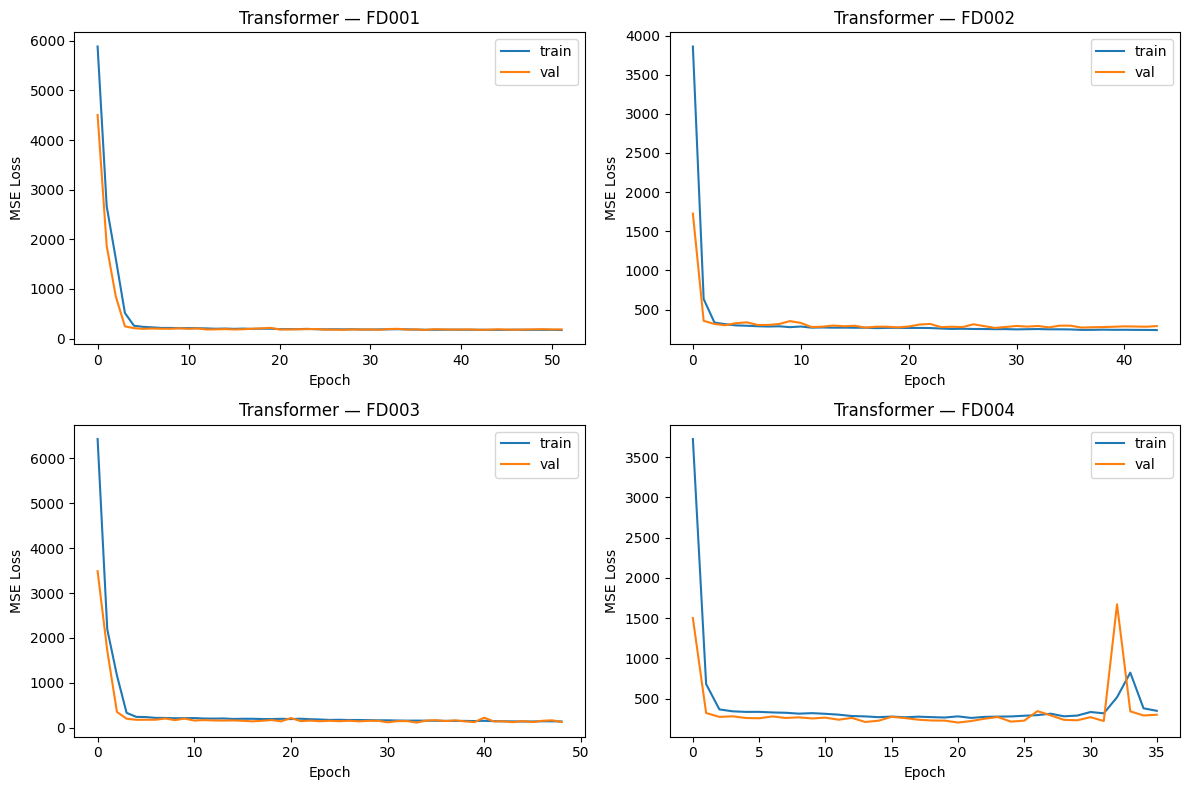

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (fd, res) in zip(axes.flatten(), results.items()):
    ax.plot(res['history']['loss'], label='train')
    ax.plot(res['history']['val_loss'], label='val')
    ax.set_title(f'Transformer — {fd}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    # Convergenza rapida in poche epoche: attention cattura subito le dipendenze globali
    ax.legend()
plt.tight_layout()
plt.savefig('../plots/04_transformer_training_curves.png', dpi=150)
plt.show()